In [1]:
import os, sys, csv, math, random, platform
from pathlib import Path
from copy import deepcopy

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

PROJECT_ROOT = Path('..')
SCRIPTS_DIR  = PROJECT_ROOT / 'scripts'
KAGGLE_ROOT  = PROJECT_ROOT / 'ArtBench-10'
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
amp_enabled = device.type == 'cuda'
print('Device:', device, '| AMP:', amp_enabled)

Device: cuda | AMP: True


In [2]:
IMAGE_SIZE     = 32
BATCH_SIZE     = 64
EPOCHS         = 500
TIMESTEPS      = 1000
BETA_START     = 1e-4
BETA_END       = 0.02
BASE_CH        = 128
T_DIM          = 256
LR             = 2e-4
WEIGHT_DECAY   = 0.0       # AdamW sem weight decay — DDPM standard
EMA_DECAY      = 0.9995
WARMUP_EPOCHS  = 10        # warmup linear
DROPOUT        = 0.1
GRAD_CLIP      = 1.0

NUM_WORKERS = 0 if platform.system() == 'Windows' else min(4, os.cpu_count() or 1)
print(f'Sistema: {platform.system()} | num_workers={NUM_WORKERS}')

Sistema: Windows | num_workers=0


In [3]:
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds    = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_hf = hf_ds['train']

# Augmentação robusta para dados artísticos
transform = T.Compose([
    T.Resize(IMAGE_SIZE + 4),           # margem para crop
    T.RandomCrop(IMAGE_SIZE),            # variação espacial
    T.RandomHorizontalFlip(p=0.5),       # simetria horizontal
    T.ColorJitter(                       # variação de cor — importante para arte
        brightness=0.05,
        contrast=0.05,
        saturation=0.05,
        hue=0.02,
    ),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # → [-1, 1]
])

class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split; self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        ex = self.ds[self.indices[idx]]
        x  = self.transform(ex['image']) if self.transform else ex['image']
        return x, int(ex['label'])

def load_csv_ids(csv_path, col='train_id_original'):
    ids = []
    with open(csv_path, 'r', encoding='utf-8') as f:
        for row in csv.DictReader(f):
            ids.append(int(row[col]))
    return ids

train_ids    = load_csv_ids(Path('training_20_percent.csv'))
train_ds     = HFDatasetTorch(train_hf, transform=transform, indices=train_ids)
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda'),
    persistent_workers=False, drop_last=True,
)

steps_per_epoch = len(train_loader)
total_steps     = EPOCHS * steps_per_epoch
print(f'Train: {len(train_ds)} imgs | Batches/epoch: {steps_per_epoch}')
print(f'Total training steps: {total_steps:,}')

Dataset source: kaggle root='..\ArtBench-10'
Train: 10000 imgs | Batches/epoch: 156
Total training steps: 78,000


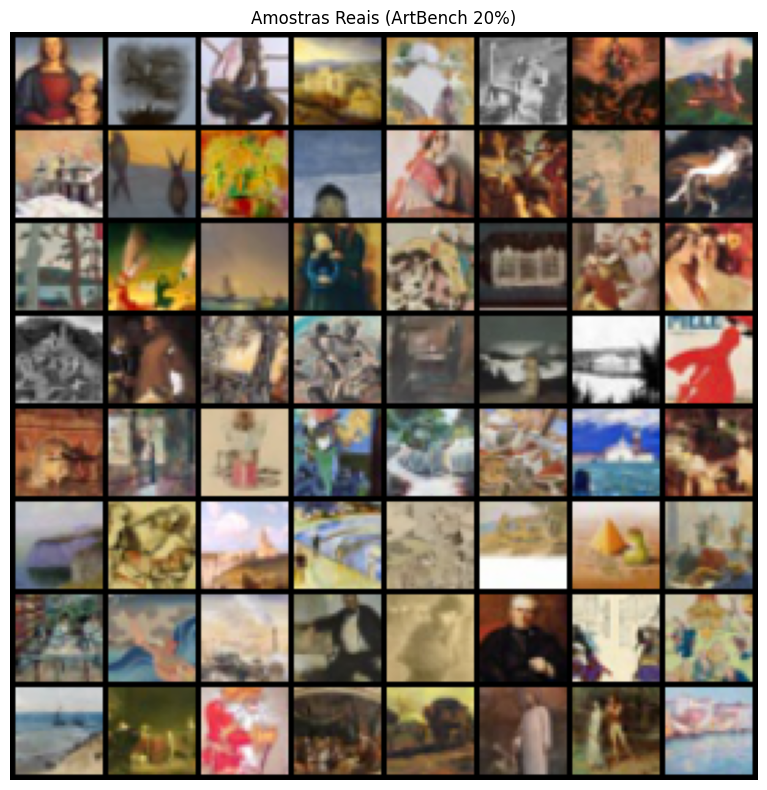

In [4]:
sample_batch, _ = next(iter(train_loader))
grid = make_grid((sample_batch[:64] + 1) / 2, nrow=8, padding=2)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).clamp(0, 1).numpy())
plt.title('Amostras Reais (ArtBench 20%)'); plt.axis('off')
plt.tight_layout(); plt.show()

In [5]:
class DDPMScheduler:
    """
    DDPM Scheduler com schedule linear.
    Compatível com 4_evaluation_artbench.ipynb.
    """
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02, device='cpu'):
        self.T = T

        beta           = torch.linspace(beta_start, beta_end, T, dtype=torch.float32).to(device)
        alpha          = 1.0 - beta
        alpha_bar      = torch.cumprod(alpha, dim=0)
        alpha_bar_prev = torch.cat([torch.ones(1, device=device), alpha_bar[:-1]])

        # Variância posterior: β̃_t = β_t * (1 - ᾱ_{t-1}) / (1 - ᾱ_t)
        post_var       = beta * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar)
        post_var[0]    = 1e-20  # evita log(0) no t=0

        self.beta                     = beta
        self.alpha                    = alpha
        self.alpha_bar                = alpha_bar
        self.posterior_variance       = post_var
        self.sqrt_recip_alpha         = torch.sqrt(1.0 / alpha)
        self.sqrt_alpha_bar           = torch.sqrt(alpha_bar)
        self.sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - alpha_bar)

    def add_noise(self, x0, t, noise=None):
        """Forward process: q(x_t | x_0) = N(√ᾱ_t x_0, (1-ᾱ_t)I)"""
        if noise is None:
            noise = torch.randn_like(x0)
        sa  = self.sqrt_alpha_bar[t].view(-1, 1, 1, 1)
        som = self.sqrt_one_minus_alpha_bar[t].view(-1, 1, 1, 1)
        return sa * x0 + som * noise, noise

    @torch.no_grad()
    def sample(self, model, n=16, image_size=32, channels=3):
        """Reverse process: gera imagens a partir de ruído puro."""
        model.eval()
        dev = self.beta.device
        x = torch.randn(n, channels, image_size, image_size, device=dev)

        for t in reversed(range(self.T)):
            tb   = torch.full((n,), t, device=dev, dtype=torch.long)
            eps  = model(x, tb)

            # μ_θ(x_t, t) = (1/√α_t) * (x_t - β_t/√(1-ᾱ_t) * ε_θ)
            mean = self.sqrt_recip_alpha[t] * (
                x - (self.beta[t] / self.sqrt_one_minus_alpha_bar[t]) * eps
            )

            if t > 0:
                x = mean + torch.sqrt(self.posterior_variance[t]) * torch.randn_like(x)
            else:
                x = mean

        return x.clamp(-1, 1)

scheduler = DDPMScheduler(
    T=TIMESTEPS, beta_start=BETA_START, beta_end=BETA_END, device=device
)
print(f'Scheduler: T={scheduler.T}, β=[{BETA_START}, {BETA_END}]')
print(f'ᾱ_T (último) = {scheduler.alpha_bar[-1]:.6f}  (deve ser ≈ 0, i.e. ruído quase puro)')

Scheduler: T=1000, β=[0.0001, 0.02]
ᾱ_T (último) = 0.000040  (deve ser ≈ 0, i.e. ruído quase puro)


In [6]:
class SinusoidalPE(nn.Module):
    def __init__(self, dim):
        super().__init__(); self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freq = torch.exp(
            torch.arange(half, device=t.device, dtype=torch.float32)
            * -(math.log(10000) / max(half - 1, 1))
        )
        emb = t.float()[:, None] * freq[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, t_dim, dropout=0.1):
        super().__init__()
        self.norm1   = nn.GroupNorm(min(8, in_ch),  in_ch)
        self.conv1   = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2   = nn.GroupNorm(min(8, out_ch), out_ch)
        self.dropout = nn.Dropout(dropout)
        self.conv2   = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.t_proj  = nn.Linear(t_dim, out_ch)
        self.skip    = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, te):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.t_proj(F.silu(te))[:, :, None, None]
        h = self.conv2(self.dropout(F.silu(self.norm2(h))))
        return h + self.skip(x)


class SelfAttention(nn.Module):
    def __init__(self, ch, heads=4):
        super().__init__()
        self.norm = nn.GroupNorm(min(8, ch), ch)
        self.attn = nn.MultiheadAttention(ch, heads, batch_first=True)

    def forward(self, x):
        b, c, h, w = x.shape
        y = self.norm(x).reshape(b, c, h * w).transpose(1, 2)
        y, _ = self.attn(y, y, y)
        return x + y.transpose(1, 2).reshape(b, c, h, w)


class Downsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.op = nn.Conv2d(ch, ch, 3, stride=2, padding=1)
    def forward(self, x): return self.op(x)


class Upsample(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.op = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
    def forward(self, x): return self.op(x)


class UNetDDPM(nn.Module):
    """
    U-Net DDPM para imagens 3×32×32.
    Arquitectura compatível com 4_evaluation_artbench.ipynb.
    """
    def __init__(self, ch=128, t_dim=256):
        super().__init__()
        # Time embedding MLP
        self.t_emb = nn.Sequential(
            SinusoidalPE(t_dim),
            nn.Linear(t_dim, t_dim * 2), nn.SiLU(),
            nn.Linear(t_dim * 2, t_dim),
        )
        self.stem   = nn.Conv2d(3, ch, 3, padding=1)

        # Encoder: 32→16→8
        self.enc1a  = ResBlock(ch,   ch,   t_dim)
        self.enc1b  = ResBlock(ch,   ch,   t_dim)
        self.down1  = Downsample(ch)

        self.enc2a  = ResBlock(ch,   ch*2, t_dim)
        self.enc2b  = ResBlock(ch*2, ch*2, t_dim)
        self.attn2  = SelfAttention(ch*2, heads=4)
        self.down2  = Downsample(ch*2)

        self.enc3a  = ResBlock(ch*2, ch*4, t_dim)
        self.enc3b  = ResBlock(ch*4, ch*4, t_dim)
        self.attn3  = SelfAttention(ch*4, heads=4)

        # Bottleneck (8×8)
        self.mid1      = ResBlock(ch*4, ch*4, t_dim)
        self.mid_attn  = SelfAttention(ch*4, heads=4)
        self.mid2      = ResBlock(ch*4, ch*4, t_dim)

        # Decoder: 8→16→32
        self.up3       = Upsample(ch*4, ch*2)
        self.dec3a     = ResBlock(ch*4, ch*2, t_dim)   # ch*4 porque concat com skip
        self.dec3b     = ResBlock(ch*2, ch*2, t_dim)
        self.dec_attn3 = SelfAttention(ch*2, heads=4)

        self.up2       = Upsample(ch*2, ch)
        self.dec2a     = ResBlock(ch*2, ch,  t_dim)    # ch*2 porque concat com skip
        self.dec2b     = ResBlock(ch,   ch,  t_dim)

        # Output
        self.out_norm  = nn.GroupNorm(min(8, ch), ch)
        self.out       = nn.Conv2d(ch, 3, 1)

        # Zero-init: modelo começa por prever zero (≈ identidade no reverse process)
        nn.init.zeros_(self.out.weight)
        nn.init.zeros_(self.out.bias)

    def forward(self, x, t):
        te = self.t_emb(t)
        x  = self.stem(x)

        # Encoder
        e1 = self.enc1b(self.enc1a(x, te), te)                       # 32×32
        x  = self.down1(e1)                                          # → 16×16
        e2 = self.attn2(self.enc2b(self.enc2a(x, te), te))           # 16×16
        x  = self.down2(e2)                                          # → 8×8
        e3 = self.attn3(self.enc3b(self.enc3a(x, te), te))           # 8×8

        # Bottleneck
        x  = self.mid2(self.mid_attn(self.mid1(e3, te)), te)         # 8×8

        # Decoder
        x  = self.up3(x)                                             # → 16×16
        x  = torch.cat([x, e2], 1)                                   # skip 16×16
        x  = self.dec_attn3(self.dec3b(self.dec3a(x, te), te))

        x  = self.up2(x)                                             # → 32×32
        x  = torch.cat([x, e1], 1)                                   # skip 32×32
        x  = self.dec2b(self.dec2a(x, te), te)

        return self.out(F.silu(self.out_norm(x)))


model  = UNetDDPM(ch=BASE_CH, t_dim=T_DIM).to(device)
params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'Parâmetros: {params:.2f}M')

# Smoke test
with torch.no_grad():
    x_t = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)
    t   = torch.randint(0, TIMESTEPS, (2,), device=device)
    print(f'Forward test: {tuple(model(x_t, t).shape)}')

Parâmetros: 29.60M
Forward test: (2, 3, 32, 32)


In [7]:
class EMA:
    """Exponential Moving Average dos pesos do modelo."""
    def __init__(self, model, decay=0.9995):
        self.decay  = decay
        self.shadow = deepcopy(model).eval()
        for p in self.shadow.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        for (k, v), (_, sv) in zip(
            model.state_dict().items(), self.shadow.state_dict().items()
        ):
            if sv.dtype.is_floating_point:
                sv.copy_(self.decay * sv + (1.0 - self.decay) * v.detach())
            else:
                sv.copy_(v)


def build_lr_lambda(total_steps, warmup_steps, min_lr_ratio=0.1):
    """
    Warmup linear + cosine decay suave.
    O LR nunca desce abaixo de min_lr_ratio * lr_base.
    """
    def fn(step):
        if step < warmup_steps:
            return (step + 1) / warmup_steps
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        cosine   = 0.5 * (1.0 + math.cos(math.pi * progress))
        return min_lr_ratio + (1.0 - min_lr_ratio) * cosine
    return fn


def save_checkpoint(model, ema, history, path, config):
    """Guarda checkpoint compatível com 4_evaluation_artbench.ipynb."""
    checkpoint = {
        'ema_state_dict': ema.shadow.state_dict(),
        'raw_state_dict': model.state_dict(),
        'config': config,
        'history': history,
    }
    torch.save(checkpoint, path)


def train_diffusion(model, scheduler, loader, epochs, lr=2e-4):
    optimizer   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    total_steps = epochs * len(loader)
    warmup_steps = WARMUP_EPOCHS * len(loader)

    lr_sched = torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=build_lr_lambda(total_steps, warmup_steps, min_lr_ratio=0.1)
    )
    scaler = torch.amp.GradScaler('cuda', enabled=amp_enabled)
    ema    = EMA(model, decay=EMA_DECAY)
    history = []

    config = {
        'base_ch':    BASE_CH,
        't_dim':      T_DIM,
        'timesteps':  TIMESTEPS,
        'schedule':   'linear',
        'beta_start': BETA_START,
        'beta_end':   BETA_END,
    }

    Path('artifacts').mkdir(exist_ok=True)
    best_loss = float('inf')

    for ep in range(epochs):
        model.train()
        total_loss = 0.0

        for x0, _ in tqdm(loader, desc=f'Epoch {ep+1}/{epochs}', leave=False):
            x0    = x0.to(device, non_blocking=True)
            bsz   = x0.size(0)
            t     = torch.randint(0, scheduler.T, (bsz,), device=device)
            noise = torch.randn_like(x0)
            xt, _ = scheduler.add_noise(x0, t, noise=noise)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=amp_enabled):
                pred = model(xt, t)
                loss = F.mse_loss(pred, noise)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            lr_sched.step()
            ema.update(model)

            total_loss += loss.item()

        epoch_loss = total_loss / len(loader)
        current_lr = optimizer.param_groups[0]['lr']
        history.append({'loss': epoch_loss, 'lr': current_lr})

        # Log a cada 25 epochs
        if (ep + 1) % 25 == 0:
            print(f'Epoch {ep+1:03d}/{epochs} | loss={epoch_loss:.5f} | lr={current_lr:.2e}')

        # Checkpoint intermédio + amostras visuais a cada 100 epochs
        if (ep + 1) % 100 == 0:
            save_checkpoint(
                model, ema, history,
                f'artifacts/diffusion_ddpm_ep{ep+1}.pt', config
            )
            # Gerar 16 amostras para ver progresso
            print(f'  → Gerando amostras de progresso (epoch {ep+1})...')
            imgs = scheduler.sample(ema.shadow, n=16, image_size=IMAGE_SIZE).cpu()
            grid = make_grid((imgs + 1) / 2, nrow=4, padding=2)
            plt.figure(figsize=(5, 5))
            plt.imshow(grid.permute(1, 2, 0).clamp(0, 1).numpy())
            plt.title(f'Amostras Epoch {ep+1}'); plt.axis('off')
            plt.tight_layout(); plt.show()
            model.train()  # voltar a train mode

        # Guardar melhor modelo
        if epoch_loss < best_loss:
            best_loss = epoch_loss
            save_checkpoint(
                model, ema, history,
                'artifacts/diffusion_ddpm_artbench_best.pt', config
            )

    print(f'\nTreino concluído! Loss final: {epoch_loss:.5f} | Melhor: {best_loss:.5f}')
    return history, ema

Epoch 1/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 2/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 3/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 4/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 5/500:   0%|          | 0/156 [00:00<?, ?it/s]

...

Epoch 97/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 98/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 99/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 100/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 100/500 | loss=0.02605 | lr=1.85e-04
  → Gerando amostras de progresso (epoch 100)...


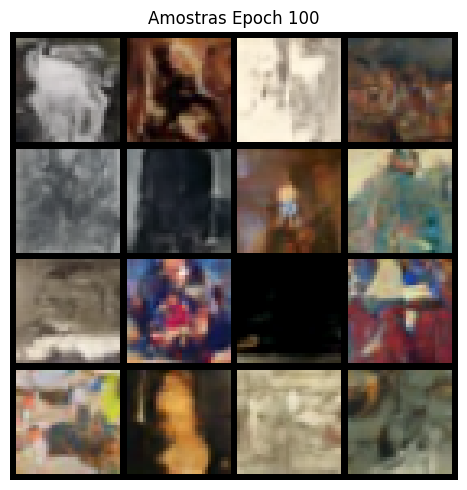

Epoch 101/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 102/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 103/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 104/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 105/500:   0%|          | 0/156 [00:00<?, ?it/s]

...

Epoch 197/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 198/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 199/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 200/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 200/500 | loss=0.02540 | lr=1.41e-04
  → Gerando amostras de progresso (epoch 200)...


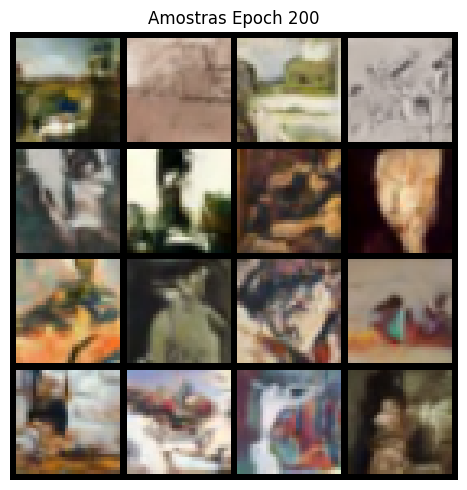

Epoch 201/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 202/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 203/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 204/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 205/500:   0%|          | 0/156 [00:00<?, ?it/s]

...

Epoch 297/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 298/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 299/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 300/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 300/500 | loss=0.02486 | lr=8.44e-05
  → Gerando amostras de progresso (epoch 300)...


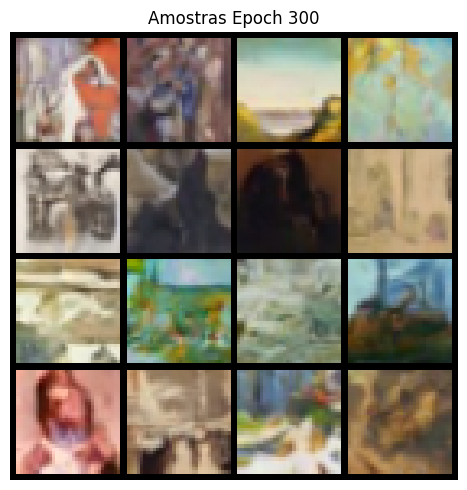

Epoch 301/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 302/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 303/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 304/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 305/500:   0%|          | 0/156 [00:00<?, ?it/s]

...

Epoch 397/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 398/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 399/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 400/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 400/500 | loss=0.02447 | lr=3.79e-05
  → Gerando amostras de progresso (epoch 400)...


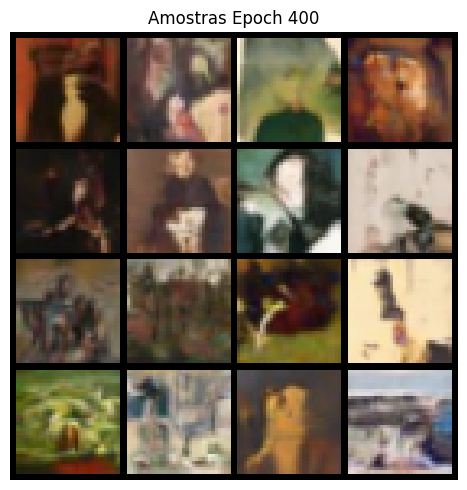

Epoch 401/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 402/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 403/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 404/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 405/500:   0%|          | 0/156 [00:00<?, ?it/s]

...

Epoch 497/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 498/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 499/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 500/500:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 500/500 | loss=0.02483 | lr=2.00e-05
  → Gerando amostras de progresso (epoch 500)...


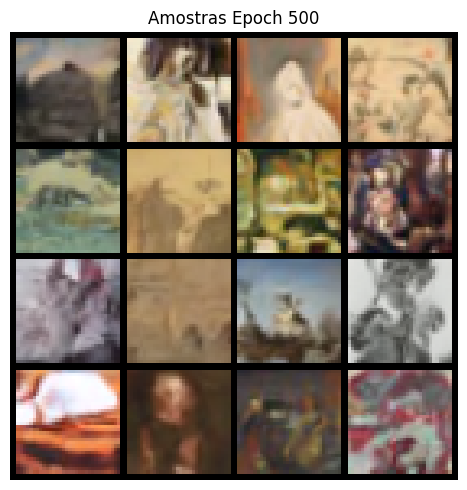


Treino concluído! Loss final: 0.02483 | Melhor: 0.02327


In [8]:
history, ema = train_diffusion(
    model, scheduler, train_loader,
    epochs=EPOCHS, lr=LR
)

In [9]:
# Checkpoint final com nome standard para o notebook de avaliação
final_config = {
    'base_ch':    BASE_CH,
    't_dim':      T_DIM,
    'timesteps':  TIMESTEPS,
    'schedule':   'linear',
    'beta_start': BETA_START,
    'beta_end':   BETA_END,
}

checkpoint = {
    'ema_state_dict': ema.shadow.state_dict(),
    'raw_state_dict': model.state_dict(),
    'config': final_config,
    'history': history,
}
torch.save(checkpoint, 'artifacts/diffusion_ddpm_artbench_checkpoint.pt')
print('Checkpoint final guardado em artifacts/diffusion_ddpm_artbench_checkpoint.pt ✅')

Checkpoint final guardado em artifacts/diffusion_ddpm_artbench_checkpoint.pt ✅


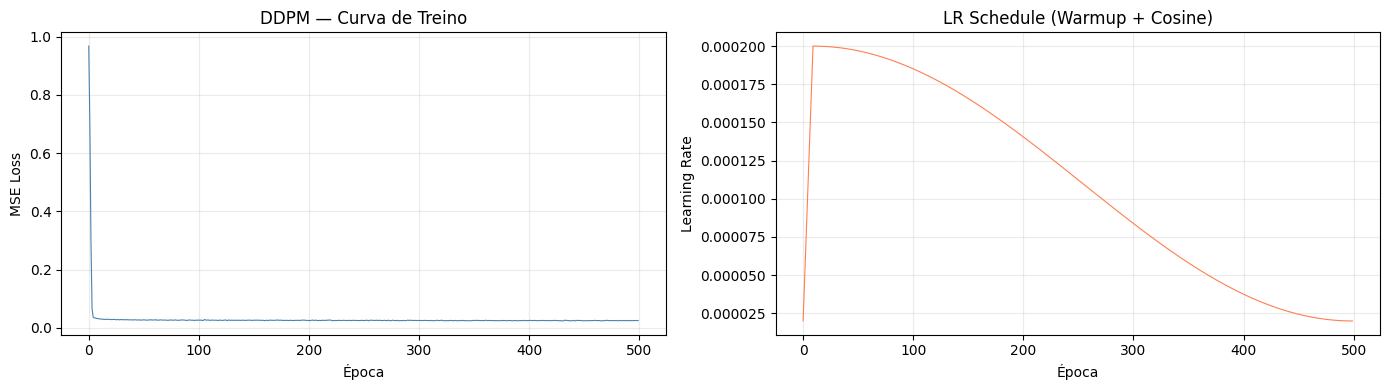

Loss final: 0.02483 | Loss mínima: 0.02327


In [10]:
def plot_history(history):
    losses = [h['loss'] for h in history]
    lrs    = [h['lr']   for h in history]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    ax1.plot(losses, color='steelblue', linewidth=0.8)
    ax1.set_xlabel('Época'); ax1.set_ylabel('MSE Loss')
    ax1.set_title('DDPM — Curva de Treino')
    ax1.grid(alpha=0.25)

    ax2.plot(lrs, color='coral', linewidth=0.8)
    ax2.set_xlabel('Época'); ax2.set_ylabel('Learning Rate')
    ax2.set_title('LR Schedule (Warmup + Cosine)')
    ax2.grid(alpha=0.25)

    plt.tight_layout(); plt.show()
    print(f'Loss final: {losses[-1]:.5f} | Loss mínima: {min(losses):.5f}')

plot_history(history)

A gerar 64 amostras com 1000 timesteps...


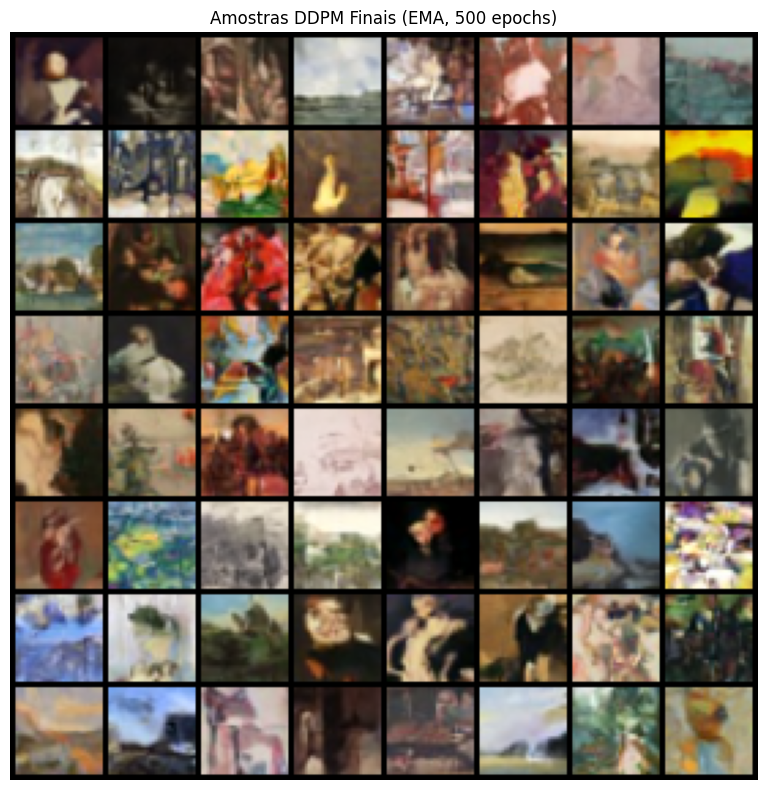

Feito! ✅


In [11]:
@torch.no_grad()
def show_samples(model, scheduler, n=64, title='Amostras DDPM (EMA)'):
    print(f'A gerar {n} amostras com {scheduler.T} timesteps...')
    imgs = scheduler.sample(model, n=n, image_size=IMAGE_SIZE).cpu()
    imgs = (imgs + 1) / 2  # [-1,1] → [0,1]
    grid = make_grid(imgs, nrow=8, padding=2)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).clamp(0, 1).numpy())
    plt.title(title); plt.axis('off')
    plt.tight_layout(); plt.show()
    print('Feito! ✅')

# Usar o modelo EMA (sempre melhor que o raw model)
show_samples(ema.shadow, scheduler, n=64, title='Amostras DDPM Finais (EMA, 500 epochs)')

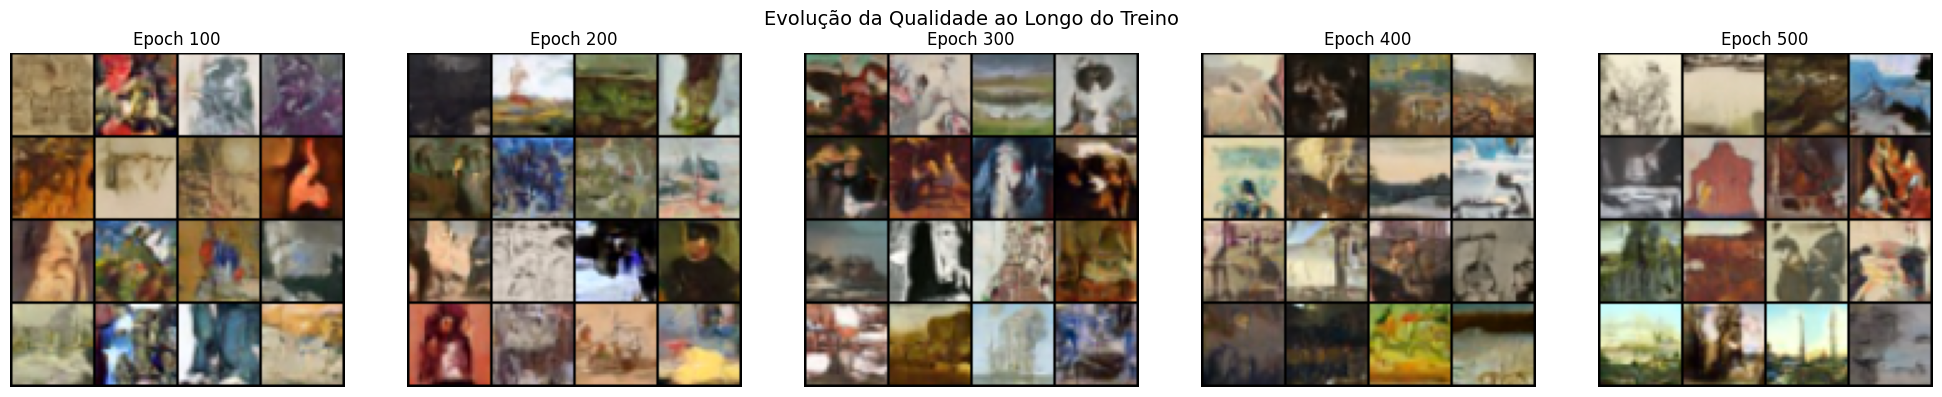

In [12]:
checkpoints_to_show = [100, 200, 300, 400, 500]
fig, axes = plt.subplots(1, len(checkpoints_to_show), figsize=(4 * len(checkpoints_to_show), 4))

for ax, ep in zip(axes, checkpoints_to_show):
    ckpt_path = f'artifacts/diffusion_ddpm_ep{ep}.pt'
    if not Path(ckpt_path).exists():
        # O último epoch pode ser o checkpoint final
        if ep == EPOCHS:
            ckpt_path = 'artifacts/diffusion_ddpm_artbench_checkpoint.pt'
        if not Path(ckpt_path).exists():
            ax.set_title(f'Epoch {ep}\n(não encontrado)'); ax.axis('off')
            continue

    ckpt = torch.load(ckpt_path, map_location=device)
    tmp_model = UNetDDPM(ch=BASE_CH, t_dim=T_DIM).to(device)
    tmp_model.load_state_dict(ckpt['ema_state_dict'])
    tmp_model.eval()

    imgs = scheduler.sample(tmp_model, n=16, image_size=IMAGE_SIZE).cpu()
    grid = make_grid((imgs + 1) / 2, nrow=4, padding=1)
    ax.imshow(grid.permute(1, 2, 0).clamp(0, 1).numpy())
    ax.set_title(f'Epoch {ep}'); ax.axis('off')
    del tmp_model

plt.suptitle('Evolução da Qualidade ao Longo do Treino', fontsize=14)
plt.tight_layout(); plt.show()